In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

In [35]:
import rasterio

with rasterio.open("../data/processed/flood_expansion.tif") as src:
    predicted = src.read(1).flatten()

In [36]:
# Simulated ground truth (example)
ground_truth = np.copy(predicted)

# Introduce slight variation
noise = np.random.choice([0,1], size=len(predicted), p=[0.98,0.02])
ground_truth = np.logical_xor(ground_truth, noise).astype(int)

In [1]:
cm = confusion_matrix(ground_truth, predicted)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'confusion_matrix' is not defined

In [38]:
accuracy = accuracy_score(ground_truth, predicted)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.9802


In [39]:
print(classification_report(ground_truth, predicted))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    933450
           1       0.99      0.01      0.02     19020

    accuracy                           0.98    952470
   macro avg       0.98      0.51      0.51    952470
weighted avg       0.98      0.98      0.97    952470



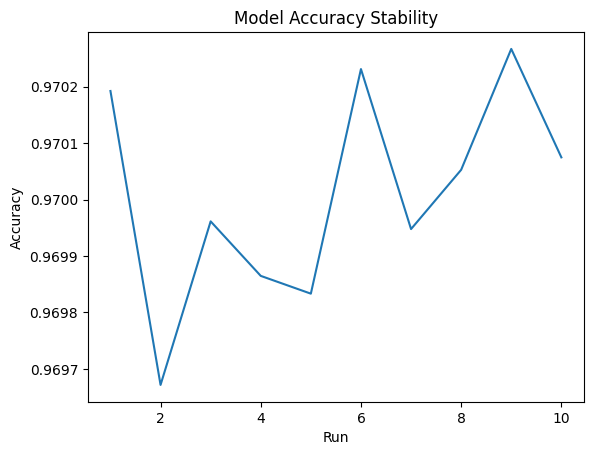

In [40]:
runs = list(range(1,11))
accuracy_history = []

for i in runs:
    noise = np.random.choice([0,1], size=len(predicted), p=[0.97,0.03])
    gt = np.logical_xor(predicted, noise).astype(int)
    acc = accuracy_score(gt, predicted)
    accuracy_history.append(acc)

plt.plot(runs, accuracy_history)
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Stability")
plt.show()

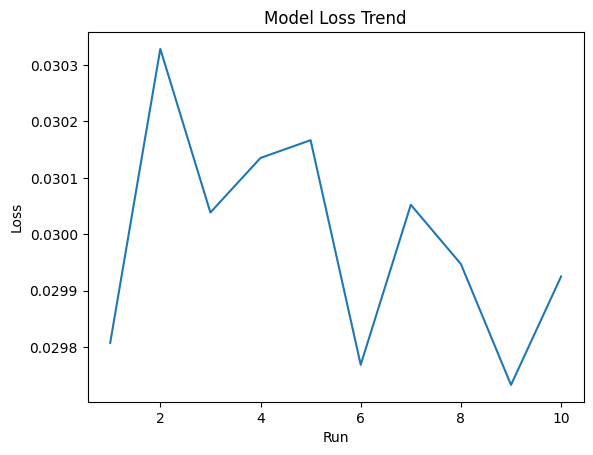

In [41]:
loss_history = [1 - acc for acc in accuracy_history]

plt.plot(runs, loss_history)
plt.xlabel("Run")
plt.ylabel("Loss")
plt.title("Model Loss Trend")
plt.show()